In [ ]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060


In [ ]:
import os, json, random, time
from dataclasses import dataclass, asdict
from typing import Dict, Any, List, Tuple, Optional

import numpy as np
import torch
import torchvision
from torchvision.transforms import functional as F

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("cuda available:", torch.cuda.is_available())


torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
cuda available: True


In [ ]:
import wandb

if os.environ.get('WANDB_API_KEY'):
    wandb.login(key=os.environ['WANDB_API_KEY'])
    print('W&B: authenticated via WANDB_API_KEY env var')
else:
    wandb.login()
    print('W&B: interactive login')


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\natha\_netrc.
wandb: Currently logged in as: jli43 (jli43-new-jersey-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B: interactive login


In [ ]:

def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id: int) -> None:
    # Deterministic DataLoader workers
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

BASE_SEED = 1337
set_global_seed(BASE_SEED)


In [ ]:
import os, time, zipfile, json as _json
import requests as _requests
from huggingface_hub import hf_hub_download

HF_DATASET_REPO  = "bryanbocao/coco_minitrain"
HF_DATASET_FILE  = "coco_minitrain_10k.zip"   # change to _25k for full run
COCO_ANN_URL     = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"

_IS_COLAB    = os.path.isdir("/content")
DATASET_BASE = "/content" if _IS_COLAB else "/workspaces/eng-ai-agents/data"
EXTRACT_ROOT = os.path.join(DATASET_BASE, "coco_minitrain")

COCO_MINITRAIN_ROOT = None
IMAGES_DIR          = None
ANN_JSON            = None
DATASET_READY       = False


def _hf_download_with_retry(repo_id, filename, repo_type, local_dir,
                             max_retries=5, base_wait=60):
    for attempt in range(max_retries):
        try:
            return hf_hub_download(repo_id=repo_id, filename=filename,
                                   repo_type=repo_type, local_dir=local_dir)
        except Exception as e:
            if "429" in str(e) and attempt < max_retries - 1:
                wait = base_wait * (2 ** attempt)
                print(f"  Rate-limited (attempt {attempt+1}/{max_retries}). Waiting {wait}s ...")
                time.sleep(wait)
            else:
                raise
    raise RuntimeError("hf_hub_download: max retries exceeded")


def _build_coco_json(images_dir, full_ann_path, out_path):
    """Filter instances_train2017.json to the image IDs present in images_dir."""
    img_files = [f for f in os.listdir(images_dir) if f.lower().endswith(".jpg")]
    present_ids = {int(os.path.splitext(f)[0]) for f in img_files}
    print(f"  Found {len(present_ids)} images in {images_dir}")
    print(f"  Loading full COCO annotations from {full_ann_path} ...")
    with open(full_ann_path) as f:
        full = _json.load(f)
    imgs  = [im for im in full["images"]      if im["id"] in present_ids]
    anns  = [an for an in full["annotations"] if an["image_id"] in present_ids]
    mini  = {
        "info":        full.get("info", {}),
        "licenses":    full.get("licenses", []),
        "categories":  full["categories"],
        "images":      imgs,
        "annotations": anns,
    }
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    with open(out_path, "w") as f:
        _json.dump(mini, f)
    print(f"  Wrote {len(imgs)} images / {len(anns)} annotations → {out_path}")


def _ensure_coco_full_annotations(ann_dir):
    """Download and extract official COCO 2017 train annotations if missing.
    The COCO zip extracts to an 'annotations/' subdir, so the final path is
    ann_dir/annotations/instances_train2017.json.
    """
    target = os.path.join(ann_dir, "annotations", "instances_train2017.json")
    if os.path.exists(target):
        return target
    os.makedirs(ann_dir, exist_ok=True)
    zip_path = os.path.join(ann_dir, "annotations_trainval2017.zip")
    print(f"  Downloading COCO 2017 annotations (~253 MB) ...")
    with _requests.get(COCO_ANN_URL, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(zip_path, "wb") as f:
            for chunk in r.iter_content(1 << 20):
                f.write(chunk)
    print("  Extracting ...")
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(ann_dir)
    os.remove(zip_path)
    return target


# ── Step 1: locate or download+extract the HF zip ────────────────────────────
extract_dir = os.path.join(EXTRACT_ROOT, HF_DATASET_FILE.replace(".zip", ""))
zip_local   = os.path.join(EXTRACT_ROOT, HF_DATASET_FILE)

if os.path.isdir(extract_dir) and os.listdir(extract_dir):
    print(f"Cached extraction found: {extract_dir}")
else:
    os.makedirs(EXTRACT_ROOT, exist_ok=True)
    try:
        if os.path.exists(zip_local):
            print(f"Zip already downloaded: {zip_local}")
        else:
            print(f"Downloading {HF_DATASET_FILE} from {HF_DATASET_REPO} ...")
            zip_local = _hf_download_with_retry(
                repo_id=HF_DATASET_REPO, filename=HF_DATASET_FILE,
                repo_type="dataset", local_dir=EXTRACT_ROOT,
            )
            print(f"Download complete: {zip_local}")
        print(f"Extracting to {extract_dir} ...")
        os.makedirs(extract_dir, exist_ok=True)
        with zipfile.ZipFile(zip_local, "r") as zf:
            zf.extractall(extract_dir)
        print("Extraction complete.")
    except Exception as e:
        print(f"HF download/extraction failed: {e}")
        extract_dir = None

# ── Step 2: locate train2017 images dir ───────────────────────────────────────
if extract_dir and os.path.isdir(extract_dir):
    # Zip extracts to coco_minitrain_10k/coco_minitrain_10k/images/train2017/
    train_imgs = os.path.join(extract_dir, os.path.basename(extract_dir),
                              "images", "train2017")
    if not os.path.isdir(train_imgs):
        best_dir, best_n = extract_dir, 0
        for dp, _, files in os.walk(extract_dir):
            n = sum(1 for f in files if f.lower().endswith(".jpg"))
            if n > best_n:
                best_dir, best_n = dp, n
        train_imgs = best_dir if best_n > 10 else None

    if train_imgs:
        IMAGES_DIR = train_imgs
        # ── Step 3: build COCO JSON if not present ─────────────────────────
        ann_dir  = os.path.join(extract_dir, "annotations")
        ann_json = os.path.join(ann_dir, "instances_minitrain.json")
        if not os.path.exists(ann_json):
            full_ann_cache = os.path.join(EXTRACT_ROOT, "coco_full_annotations")
            full_ann_path  = _ensure_coco_full_annotations(full_ann_cache)
            _build_coco_json(IMAGES_DIR, full_ann_path, ann_json)
        else:
            print(f"Annotation JSON already exists: {ann_json}")
        ANN_JSON            = ann_json
        COCO_MINITRAIN_ROOT = extract_dir
        DATASET_READY       = True
        print(f"Dataset ready:")
        print(f"  Root:        {COCO_MINITRAIN_ROOT}")
        print(f"  Annotations: {ANN_JSON}")
        print(f"  Images:      {IMAGES_DIR}")
    else:
        print(f"WARNING: could not locate train2017 images inside {extract_dir}")

# ── Step 4: fallback — git clone (annotations only) ──────────────────────────
if not DATASET_READY:
    print("\nFalling back to git clone of coco-minitrain (annotations only).")
    for p in ["coco-minitrain", "/content/coco-minitrain",
               os.path.expanduser("~/coco-minitrain")]:
        if os.path.isdir(p):
            COCO_MINITRAIN_ROOT = p
            break
    if COCO_MINITRAIN_ROOT is None:
        os.system("git clone --depth 1 https://github.com/giddyyupp/coco-minitrain.git")
        COCO_MINITRAIN_ROOT = "coco-minitrain"
    IMAGES_DIR = os.path.join(COCO_MINITRAIN_ROOT, "images")
    ANN_JSON   = os.path.join(COCO_MINITRAIN_ROOT, "annotations", "instances_minitrain.json")
    if os.path.exists(ANN_JSON):
        DATASET_READY = True
        print(f"Using local clone: {COCO_MINITRAIN_ROOT}")
    else:
        print("WARNING: Dataset not ready — no annotation file found.")

print(f"\nDATASET_READY : {DATASET_READY}")
if DATASET_READY:
    print(f"ANN_JSON      : {ANN_JSON}")
    print(f"IMAGES_DIR    : {IMAGES_DIR}")

Cached extraction found: /workspaces/eng-ai-agents/data\coco_minitrain\coco_minitrain_10k
Annotation JSON already exists: /workspaces/eng-ai-agents/data\coco_minitrain\coco_minitrain_10k\annotations\instances_minitrain.json
Dataset ready:
  Root:        /workspaces/eng-ai-agents/data\coco_minitrain\coco_minitrain_10k
  Annotations: /workspaces/eng-ai-agents/data\coco_minitrain\coco_minitrain_10k\annotations\instances_minitrain.json
  Images:      /workspaces/eng-ai-agents/data\coco_minitrain\coco_minitrain_10k\coco_minitrain_10k\images\train2017

DATASET_READY : True
ANN_JSON      : /workspaces/eng-ai-agents/data\coco_minitrain\coco_minitrain_10k\annotations\instances_minitrain.json
IMAGES_DIR    : /workspaces/eng-ai-agents/data\coco_minitrain\coco_minitrain_10k\coco_minitrain_10k\images\train2017


In [ ]:

from pycocotools.coco import COCO
from PIL import Image

coco = COCO(ANN_JSON)
img_ids = sorted(coco.getImgIds())
print("num images:", len(img_ids))

# Deterministic split
val_frac = 0.2
rng = np.random.default_rng(BASE_SEED)
perm = rng.permutation(len(img_ids))
n_val = int(len(img_ids) * val_frac)
val_ids = [img_ids[i] for i in perm[:n_val]]
train_ids = [img_ids[i] for i in perm[n_val:]]

print("train:", len(train_ids), "val:", len(val_ids))

SPLIT_DIR = os.path.join(COCO_MINITRAIN_ROOT, "splits")
os.makedirs(SPLIT_DIR, exist_ok=True)
with open(os.path.join(SPLIT_DIR, "train_ids.json"), "w") as f:
    json.dump(train_ids, f)
with open(os.path.join(SPLIT_DIR, "val_ids.json"), "w") as f:
    json.dump(val_ids, f)

print("Saved split ids to:", SPLIT_DIR)


loading annotations into memory...
Done (t=0.92s)
creating index...
index created!
num images: 10000
train: 8000 val: 2000
Saved split ids to: /workspaces/eng-ai-agents/data\coco_minitrain\coco_minitrain_10k\splits


In [ ]:

from torch.utils.data import Dataset, DataLoader

class CocoMiniTrainDataset(Dataset):
    def __init__(self, coco: COCO, image_dir: str, img_ids: List[int], train: bool = True):
        self.coco = coco
        self.image_dir = image_dir
        self.img_ids = img_ids
        self.train = train

    def __len__(self) -> int:
        return len(self.img_ids)

    def __getitem__(self, idx: int):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs([img_id])[0]
        img_path = os.path.join(self.image_dir, img_info["file_name"])
        image = Image.open(img_path).convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=[img_id], iscrowd=None)
        anns = self.coco.loadAnns(ann_ids)

        boxes = []
        labels = []
        areas = []
        iscrowd = []

        for a in anns:
            # COCO bbox: [x,y,w,h] -> [x1,y1,x2,y2]
            x, y, w, h = a["bbox"]
            if w <= 1 or h <= 1:
                continue
            boxes.append([x, y, x + w, y + h])
            labels.append(a["category_id"])
            areas.append(a.get("area", w * h))
            iscrowd.append(a.get("iscrowd", 0))

        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        areas = torch.as_tensor(areas, dtype=torch.float32)
        iscrowd = torch.as_tensor(iscrowd, dtype=torch.int64)

        image_t = F.to_tensor(image)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([img_id]),
            "area": areas,
            "iscrowd": iscrowd,
        }
        return image_t, target

def collate_fn(batch):
    return tuple(zip(*batch))

train_ds = CocoMiniTrainDataset(coco, IMAGES_DIR, train_ids, train=True)
val_ds   = CocoMiniTrainDataset(coco, IMAGES_DIR, val_ids, train=False)

print("train len:", len(train_ds), "val len:", len(val_ds))


train len: 8000 val len: 2000


In [ ]:

BATCH_SIZE = 2  # adjust to GPU memory
NUM_WORKERS = 0

g = torch.Generator()
g.manual_seed(BASE_SEED)

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=collate_fn,
    worker_init_fn=seed_worker, generator=g
)
val_loader = DataLoader(
    val_ds, batch_size=1, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=collate_fn,
    worker_init_fn=seed_worker, generator=g
)

next(iter(train_loader))[0][0].shape


torch.Size([3, 439, 640])


## 4. Model: Faster R-CNN (torchvision)

You will use:

- `torchvision.models.detection.fasterrcnn_resnet50_fpn`

You will also tune **RPN** and **RoI head** hyperparameters in later stages.


In [ ]:

from torchvision.models.detection import fasterrcnn_resnet50_fpn

def build_model(num_classes: Optional[int] = None):
    model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
    if num_classes is not None:
        in_features = model.roi_heads.box_predictor.cls_score.in_features
        model.roi_heads.box_predictor = torchvision.models.detection.faster_rcnn.FastRCNNPredictor(in_features, num_classes)
    return model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model().to(device)
print("Model loaded on:", device)


Model loaded on: cuda



## 5. Training and evaluation

You will implement:
- a training loop that logs loss components
- COCO evaluation via `pycocotools.cocoeval.COCOeval`

### Important notes
- COCO category IDs are not always contiguous. Torchvision expects contiguous class indices when you replace heads.
- For this assignment you will **keep the default COCO label space** and use the pretrained COCO model, then fine-tune on COCO MiniTrain.


In [ ]:

from pycocotools.cocoeval import COCOeval

@torch.no_grad()
def evaluate_coco_map(model, coco_gt: COCO, data_loader: DataLoader, max_dets: int = 100):
    model.eval()
    results = []

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for out, tgt in zip(outputs, targets):
            img_id = int(tgt["image_id"].item())

            boxes = out["boxes"].detach().cpu().numpy()
            scores = out["scores"].detach().cpu().numpy()
            labels = out["labels"].detach().cpu().numpy()

            for b, s, c in zip(boxes, scores, labels):
                x1, y1, x2, y2 = b.tolist()
                w = max(0.0, x2 - x1)
                h = max(0.0, y2 - y1)
                results.append({
                    "image_id": img_id,
                    "category_id": int(c),
                    "bbox": [x1, y1, w, h],
                    "score": float(s),
                })

    if len(results) == 0:
        return {"mAP": 0.0, "AP50": 0.0, "AP75": 0.0}

    coco_dt = coco_gt.loadRes(results)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType="bbox")
    coco_eval.params.maxDets = [max_dets, max_dets, max_dets]
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    mAP = float(coco_eval.stats[0])
    AP50 = float(coco_eval.stats[1])
    AP75 = float(coco_eval.stats[2])
    return {"mAP": mAP, "AP50": AP50, "AP75": AP75}

def train_one_epoch(model, optimizer, data_loader: DataLoader, epoch: int, max_norm: float = 0.0):
    model.train()
    loss_sums = {"loss": 0.0}
    n = 0

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad(set_to_none=True)
        losses.backward()

        if max_norm and max_norm > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)

        optimizer.step()

        # accumulate
        n += 1
        loss_sums["loss"] += float(losses.item())
        for k, v in loss_dict.items():
            loss_sums[k] = loss_sums.get(k, 0.0) + float(v.item())

    for k in loss_sums:
        loss_sums[k] /= max(1, n)
    return loss_sums


In [ ]:
from torch.optim import SGD
from torch.optim.lr_scheduler import StepLR
import wandb

wandb.finish()

In [ ]:
os.makedirs("checkpoints", exist_ok=True)


from torch.optim import SGD
from torch.optim.lr_scheduler import StepLR

BASELINE_CFG = {
    "seed": BASE_SEED,
    "epochs": int(os.environ.get("BASELINE_EPOCHS", 3)),
    "lr": 0.005,
    "momentum": 0.9,
    "weight_decay": 1e-4,
    "grad_clip_norm": 0.0,
    "step_size": 6,
    "gamma": 0.1,
    "batch_size": BATCH_SIZE,
}

set_global_seed(BASELINE_CFG["seed"])

run = wandb.init(
    project="faster-rcnn-optuna-coco-minitrain",
    name="baseline",
    config=BASELINE_CFG
)

model = build_model().to(device)

optimizer = SGD(
    model.parameters(),
    lr=BASELINE_CFG["lr"],
    momentum=BASELINE_CFG["momentum"],
    weight_decay=BASELINE_CFG["weight_decay"]
)

scheduler = StepLR(optimizer, step_size=BASELINE_CFG["step_size"], gamma=BASELINE_CFG["gamma"])

for epoch in range(BASELINE_CFG["epochs"]):
    t0 = time.time()
    losses = train_one_epoch(model, optimizer, train_loader, epoch, max_norm=BASELINE_CFG["grad_clip_norm"])
    scheduler.step()
    metrics = evaluate_coco_map(model, coco, val_loader)

    log_dict = {**losses, **{f"val_{k}": v for k, v in metrics.items()}, "epoch": epoch, "lr": scheduler.get_last_lr()[0], "epoch_time_s": time.time()-t0}
    wandb.log(log_dict)
    print(f"Epoch {epoch}: loss={losses['loss']:.4f} val_mAP={metrics['mAP']:.4f}")

BASELINE_CKPT = os.path.join("checkpoints", "baseline_fasterrcnn.pt")
torch.save(model.state_dict(), BASELINE_CKPT)
wandb.save(BASELINE_CKPT)
wandb.finish()

print("Saved:", BASELINE_CKPT)


Loading and preparing results...
DONE (t=0.36s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=21.75s).
Accumulating evaluation results...
DONE (t=3.94s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.055
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.095
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.059
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.036
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.062
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.067
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.083
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.083
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.083
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.


epoch,▁▅█
epoch_time_s,█▂▁
loss,█▄▁
loss_box_reg,█▅▁
loss_classifier,█▄▁
loss_objectness,█▃▁
loss_rpn_box_reg,█▄▁
lr,▁▁▁
val_AP50,▄▁█
val_AP75,▅▁█
+1,...


Saved: checkpoints\baseline_fasterrcnn.pt


In [ ]:
import torch
import torchvision
import wandb
import numpy as np
import random
import optuna

from typing import Dict, Any

def make_optimizer(model, lr: float, momentum: float, weight_decay: float):
    return SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

sampler = optuna.samplers.TPESampler(seed=BASE_SEED)
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)

In [ ]:

import optuna

def make_optimizer(model, lr: float, momentum: float, weight_decay: float):
    return SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)

def objective_stage1(trial: optuna.Trial) -> float:
    cfg = {
        "stage": "stage1_opt",
        "seed": int(trial.suggest_int("seed", 1, 10_000)),
        "epochs": 3, # fixed due to hardware limitations
        "lr": float(trial.suggest_float("lr", 1e-5, 1e-2, log=True)),
        "weight_decay": float(trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)),
        "momentum": float(trial.suggest_float("momentum", 0.8, 0.99)),
        "grad_clip_norm": float(trial.suggest_float("grad_clip_norm", 0.0, 5.0)),
    }

    set_global_seed(cfg["seed"])

    run = wandb.init(
        project="faster-rcnn-optuna-coco-minitrain",
        name=f"optuna_stage1_trial_{trial.number:04d}",
        config=cfg,
        reinit=True
    )

    model = build_model().to(device)
    optimizer = make_optimizer(model, cfg["lr"], cfg["momentum"], cfg["weight_decay"])

    best_map = -1.0
    for epoch in range(cfg["epochs"]):
        losses = train_one_epoch(model, optimizer, train_loader, epoch, max_norm=cfg["grad_clip_norm"])
        metrics = evaluate_coco_map(model, coco, val_loader)

        val_map = metrics["mAP"]
        best_map = max(best_map, val_map)

        wandb.log({**losses, **{f"val_{k}": v for k, v in metrics.items()}, "epoch": epoch})

        trial.report(val_map, step=epoch)
        if trial.should_prune():
            wandb.log({"pruned": 1, "best_val_mAP": best_map})
            wandb.finish()
            raise optuna.exceptions.TrialPruned()

    wandb.log({"best_val_mAP": best_map, "pruned": 0})
    wandb.finish()
    return best_map

sampler = optuna.samplers.TPESampler(seed=BASE_SEED)
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1)

study_stage1 = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner, study_name="stage1_opt")


[I 2026-03-15 15:42:31,951] A new study created in memory with name: stage1_opt


In [ ]:

# Run Stage 1 study
N_TRIALS_STAGE1 = int(os.environ.get("HPO_TRIALS", 4))  # default 3 for demo, 30 for assignment
study_stage1.optimize(objective_stage1, n_trials=N_TRIALS_STAGE1, show_progress_bar=True)

print("Best Stage 1:", study_stage1.best_value)
print("Best params:", study_stage1.best_params)


  0%|          | 0/4 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.25s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=10.83s).
Accumulating evaluation results...
DONE (t=1.88s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.101
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.149
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.112
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.070
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.111
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.128
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.120
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.120
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.120
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

best_val_mAP,▁
epoch,▁▅█
loss,▁▄█
loss_box_reg,▁▄█
loss_classifier,▁▄█
loss_objectness,▁▃█
loss_rpn_box_reg,▁▄█
pruned,▁
val_AP50,█▅▁
val_AP75,█▅▁
+1,...


[I 2026-03-13 21:10:45,694] Trial 1 finished with value: 0.10129967517766257 and parameters: {'seed': 5184, 'lr': 6.107012046824547e-05, 'weight_decay': 0.008023080310991759, 'momentum': 0.9392347650111916, 'grad_clip_norm': 0.5763711334157473}. Best is trial 1 with value: 0.10129967517766257.


Loading and preparing results...
DONE (t=0.06s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=11.08s).
Accumulating evaluation results...
DONE (t=2.20s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.076
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.126
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.082
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.051
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.085
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.095
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.102
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.102
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.102
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

...

best_val_mAP,▁
epoch,▁▅█
loss,█▄▁
loss_box_reg,█▄▁
loss_classifier,█▄▁
loss_objectness,█▄▁
loss_rpn_box_reg,█▄▁
pruned,▁
val_AP50,▅█▁
val_AP75,▆█▁
+1,...


[I 2026-03-14 00:02:17,952] Trial 3 finished with value: 0.09217480302480689 and parameters: {'seed': 7896, 'lr': 0.002411880172908875, 'weight_decay': 2.7864181456981927e-05, 'momentum': 0.8790597485184897, 'grad_clip_norm': 2.9212906405516073}. Best is trial 1 with value: 0.10129967517766257.


Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=11.14s).
Accumulating evaluation results...
DONE (t=1.81s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.103
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.152
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.115
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.071
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.113
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.129
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.121
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.121
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.121
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

best_val_mAP,▁
epoch,▁▅█
loss,█▄▁
loss_box_reg,█▄▁
loss_classifier,█▄▁
loss_objectness,█▃▁
loss_rpn_box_reg,█▃▁
pruned,▁
val_AP50,█▄▁
val_AP75,▆▁█
+1,...


[I 2026-03-14 01:28:19,740] Trial 4 finished with value: 0.10306821168209246 and parameters: {'seed': 7602, 'lr': 3.659529195469846e-05, 'weight_decay': 1.4212438265209221e-05, 'momentum': 0.9273415830504445, 'grad_clip_norm': 2.4982413068600624}. Best is trial 4 with value: 0.10306821168209246.
Best Stage 1: 0.10306821168209246
Best params: {'seed': 7602, 'lr': 3.659529195469846e-05, 'weight_decay': 1.4212438265209221e-05, 'momentum': 0.9273415830504445, 'grad_clip_norm': 2.4982413068600624}


In [ ]:
best_stage1_params = {
    "seed": 7602,
    "lr": 3.659529195469846e-05,
    "weight_decay": 1.4212438265209221e-05,
    "momentum": 0.9273415830504445,
    "grad_clip_norm": 2.4982413068600624,
}

In [ ]:

def apply_rpn_hparams(model, cfg: Dict[str, Any]):
    rpn = model.rpn

    if "rpn_nms_thresh" in cfg:
        rpn.nms_thresh = float(cfg["rpn_nms_thresh"])

    # ---- pre NMS top-k ----
    if "rpn_pre_nms_topk" in cfg:
        val = int(cfg["rpn_pre_nms_topk"])
        if isinstance(getattr(rpn, "pre_nms_top_n", None), dict):
            rpn.pre_nms_top_n["training"] = val
            rpn.pre_nms_top_n["testing"] = val
        elif hasattr(rpn, "_pre_nms_top_n"):
            rpn._pre_nms_top_n["training"] = val
            rpn._pre_nms_top_n["testing"] = val

    # ---- post NMS top-k ----
    if "rpn_post_nms_topk" in cfg:
        val = int(cfg["rpn_post_nms_topk"])
        if isinstance(getattr(rpn, "post_nms_top_n", None), dict):
            rpn.post_nms_top_n["training"] = val
            rpn.post_nms_top_n["testing"] = val
        elif hasattr(rpn, "_post_nms_top_n"):
            rpn._post_nms_top_n["training"] = val
            rpn._post_nms_top_n["testing"] = val

    if "rpn_fg_iou_thresh" in cfg:
        rpn.fg_iou_thresh = float(cfg["rpn_fg_iou_thresh"])

    if "rpn_bg_iou_thresh" in cfg:
        rpn.bg_iou_thresh = float(cfg["rpn_bg_iou_thresh"])

    if "rpn_batch_size_per_image" in cfg:
        rpn.batch_size_per_image = int(cfg["rpn_batch_size_per_image"])

    if "rpn_positive_fraction" in cfg:
        rpn.positive_fraction = float(cfg["rpn_positive_fraction"])

def objective_stage2(trial: optuna.Trial) -> float:
    # Fix Stage 1 best optimizer params
    best1 = best_stage1_params
    cfg = {
        "stage": "stage2_rpn",
        "seed": int(trial.suggest_int("seed", 1, 10_000)),
        "epochs": 3,  # keep small for HPO budget
        "lr": float(best1["lr"]),
        "weight_decay": float(best1["weight_decay"]),
        "momentum": float(best1["momentum"]),
        "grad_clip_norm": float(best1.get("grad_clip_norm", 0.0)),
        # RPN search
        "rpn_nms_thresh": float(trial.suggest_float("rpn_nms_thresh", 0.5, 0.9)),
        "rpn_pre_nms_topk": int(trial.suggest_int("rpn_pre_nms_topk", 1000, 4000)),
        "rpn_post_nms_topk": int(trial.suggest_int("rpn_post_nms_topk", 300, 2000)),
        "rpn_fg_iou_thresh": float(trial.suggest_float("rpn_fg_iou_thresh", 0.5, 0.8)),
        "rpn_bg_iou_thresh": float(trial.suggest_float("rpn_bg_iou_thresh", 0.0, 0.4)),
        "rpn_batch_size_per_image": int(trial.suggest_int("rpn_batch_size_per_image", 128, 512)),
        "rpn_positive_fraction": float(trial.suggest_float("rpn_positive_fraction", 0.25, 0.75)),
    }

    set_global_seed(cfg["seed"])

    run = wandb.init(
        project="faster-rcnn-optuna-coco-minitrain",
        name=f"optuna_stage2_trial_{trial.number:04d}",
        config=cfg,
        reinit=True
    )

    model = build_model().to(device)
    apply_rpn_hparams(model, cfg)
    optimizer = make_optimizer(model, cfg["lr"], cfg["momentum"], cfg["weight_decay"])

    best_map = -1.0
    for epoch in range(cfg["epochs"]):
        losses = train_one_epoch(model, optimizer, train_loader, epoch, max_norm=cfg["grad_clip_norm"])
        metrics = evaluate_coco_map(model, coco, val_loader)
        val_map = metrics["mAP"]
        best_map = max(best_map, val_map)

        wandb.log({**losses, **{f"val_{k}": v for k, v in metrics.items()}, "epoch": epoch})
        trial.report(val_map, step=epoch)
        if trial.should_prune():
            wandb.log({"pruned": 1, "best_val_mAP": best_map})
            wandb.finish()
            raise optuna.exceptions.TrialPruned()

    wandb.log({"best_val_mAP": best_map, "pruned": 0})
    wandb.finish()
    return best_map

study_stage2 = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner, study_name="stage2_rpn")


[I 2026-03-15 15:42:44,494] A new study created in memory with name: stage2_rpn


In [ ]:

# Run Stage 2 study
N_TRIALS_STAGE2 = int(os.environ.get("HPO_TRIALS", 4))  # default 3 for demo, 30 for assignment
study_stage2.optimize(objective_stage2, n_trials=N_TRIALS_STAGE2, show_progress_bar=True)

print("Best Stage 2:", study_stage2.best_value)
print("Best params:", study_stage2.best_params)


  0%|          | 0/4 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.05s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=10.66s).
Accumulating evaluation results...
DONE (t=1.63s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.103
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.153
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.112
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.069
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.113
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.127
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.119
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.119
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.119
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

best_val_mAP,▁
epoch,▁▅█
loss,█▃▁
loss_box_reg,█▄▁
loss_classifier,█▄▁
loss_objectness,█▃▁
loss_rpn_box_reg,█▃▁
pruned,▁
val_AP50,█▁▁
val_AP75,█▆▁
+1,...


[I 2026-03-14 03:43:56,347] Trial 0 finished with value: 0.10255000804539216 and parameters: {'seed': 7329, 'rpn_nms_thresh': 0.5461096906732598, 'rpn_pre_nms_topk': 2159, 'rpn_post_nms_topk': 1369, 'rpn_fg_iou_thresh': 0.5375173779006799, 'rpn_bg_iou_thresh': 0.3934194420574565, 'rpn_batch_size_per_image': 298, 'rpn_positive_fraction': 0.6447791710119516}. Best is trial 0 with value: 0.10255000804539216.


Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=10.85s).
Accumulating evaluation results...
DONE (t=1.78s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.103
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.152
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.115
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.070
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.114
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.131
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.121
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.121
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.121
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

...

best_val_mAP,▁
epoch,▁▅█
loss,█▄▁
loss_box_reg,█▄▁
loss_classifier,█▄▁
loss_objectness,█▄▁
loss_rpn_box_reg,█▄▁
pruned,▁
val_AP50,▁█▇
val_AP75,█▁▁
+1,...


[I 2026-03-14 06:27:48,245] Trial 2 finished with value: 0.10255424592700425 and parameters: {'seed': 4997, 'rpn_nms_thresh': 0.5714274708654108, 'rpn_pre_nms_topk': 2239, 'rpn_post_nms_topk': 638, 'rpn_fg_iou_thresh': 0.659509821076111, 'rpn_bg_iou_thresh': 0.33294828122719305, 'rpn_batch_size_per_image': 199, 'rpn_positive_fraction': 0.7286796118356303}. Best is trial 1 with value: 0.10332148711685032.


Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=9.66s).
Accumulating evaluation results...
DONE (t=1.50s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.104
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.151
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.116
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.070
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.113
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.133
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

best_val_mAP,▁
epoch,▁▅█
loss,█▃▁
loss_box_reg,█▃▁
loss_classifier,█▃▁
loss_objectness,█▄▁
loss_rpn_box_reg,█▅▁
pruned,▁
val_AP50,▄█▁
val_AP75,█▁▄
+1,...


[I 2026-03-14 07:48:08,828] Trial 3 finished with value: 0.10355763397446613 and parameters: {'seed': 4255, 'rpn_nms_thresh': 0.7016028156645749, 'rpn_pre_nms_topk': 2531, 'rpn_post_nms_topk': 326, 'rpn_fg_iou_thresh': 0.7195070206002873, 'rpn_bg_iou_thresh': 0.39732201595633176, 'rpn_batch_size_per_image': 190, 'rpn_positive_fraction': 0.3133173898454188}. Best is trial 3 with value: 0.10355763397446613.
Best Stage 2: 0.10355763397446613
Best params: {'seed': 4255, 'rpn_nms_thresh': 0.7016028156645749, 'rpn_pre_nms_topk': 2531, 'rpn_post_nms_topk': 326, 'rpn_fg_iou_thresh': 0.7195070206002873, 'rpn_bg_iou_thresh': 0.39732201595633176, 'rpn_batch_size_per_image': 190, 'rpn_positive_fraction': 0.3133173898454188}


In [ ]:
best_stage1_params = {
    "seed": 7602,
    "lr": 3.659529195469846e-05,
    "weight_decay": 1.4212438265209221e-05,
    "momentum": 0.9273415830504445,
    "grad_clip_norm": 2.4982413068600624,
}

best_stage2_params = {
    "seed": 4255,
    "rpn_nms_thresh": 0.7016028156645749,
    "rpn_pre_nms_topk": 2531,
    "rpn_post_nms_topk": 326,
    "rpn_fg_iou_thresh": 0.7195070206002873,
    "rpn_bg_iou_thresh": 0.39732201595633176,
    "rpn_batch_size_per_image": 190,
    "rpn_positive_fraction": 0.3133173898454188,
}

In [ ]:

def apply_roi_hparams(model, cfg: Dict[str, Any]):
    roi = model.roi_heads
    if "roi_batch_size_per_image" in cfg: roi.batch_size_per_image = int(cfg["roi_batch_size_per_image"])
    if "roi_positive_fraction" in cfg: roi.positive_fraction = float(cfg["roi_positive_fraction"])

def train_one_epoch_weighted(model, optimizer, data_loader: DataLoader, epoch: int, max_norm: float, cls_w: float, box_w: float):
    model.train()
    loss_sums = {"loss": 0.0}
    n = 0

    for images, targets in data_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        # Scale RoI losses; keep RPN terms unscaled by default.
        if "loss_classifier" in loss_dict:
            loss_dict["loss_classifier"] = loss_dict["loss_classifier"] * cls_w
        if "loss_box_reg" in loss_dict:
            loss_dict["loss_box_reg"] = loss_dict["loss_box_reg"] * box_w

        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad(set_to_none=True)
        losses.backward()
        if max_norm and max_norm > 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
        optimizer.step()

        n += 1
        loss_sums["loss"] += float(losses.item())
        for k, v in loss_dict.items():
            loss_sums[k] = loss_sums.get(k, 0.0) + float(v.item())

    for k in loss_sums:
        loss_sums[k] /= max(1, n)
    return loss_sums

def objective_stage3(trial: optuna.Trial) -> float:
    best1 = best_stage1_params
    best2 = best_stage2_params

    cfg = {
        "stage": "stage3_roi",
        "seed": int(trial.suggest_int("seed", 1, 10_000)),
        "epochs": 3,
        "lr": float(best1["lr"]),
        "weight_decay": float(best1["weight_decay"]),
        "momentum": float(best1["momentum"]),
        "grad_clip_norm": float(best1.get("grad_clip_norm", 0.0)),
        # RPN fixed (best2)
        **{k: best2[k] for k in best2 if k.startswith("rpn_")},
        # RoI search
        "roi_batch_size_per_image": int(trial.suggest_int("roi_batch_size_per_image", 128, 512)),
        "roi_positive_fraction": float(trial.suggest_float("roi_positive_fraction", 0.1, 0.5)),
        "cls_loss_weight": float(trial.suggest_float("cls_loss_weight", 0.5, 2.0)),
        "box_loss_weight": float(trial.suggest_float("box_loss_weight", 0.5, 2.0)),
    }

    set_global_seed(cfg["seed"])
    run = wandb.init(
        project="faster-rcnn-optuna-coco-minitrain",
        name=f"optuna_stage3_trial_{trial.number:04d}",
        config=cfg,
        reinit=True
    )

    model = build_model().to(device)
    apply_rpn_hparams(model, cfg)
    apply_roi_hparams(model, cfg)

    optimizer = make_optimizer(model, cfg["lr"], cfg["momentum"], cfg["weight_decay"])

    best_map = -1.0
    for epoch in range(cfg["epochs"]):
        losses = train_one_epoch_weighted(
            model, optimizer, train_loader, epoch,
            max_norm=cfg["grad_clip_norm"],
            cls_w=cfg["cls_loss_weight"],
            box_w=cfg["box_loss_weight"],
        )
        metrics = evaluate_coco_map(model, coco, val_loader)
        val_map = metrics["mAP"]
        best_map = max(best_map, val_map)

        wandb.log({**losses, **{f"val_{k}": v for k, v in metrics.items()}, "epoch": epoch})
        trial.report(val_map, step=epoch)
        if trial.should_prune():
            wandb.log({"pruned": 1, "best_val_mAP": best_map})
            wandb.finish()
            raise optuna.exceptions.TrialPruned()

    wandb.log({"best_val_mAP": best_map, "pruned": 0})
    wandb.finish()
    return best_map

study_stage3 = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner, study_name="stage3_roi")


[I 2026-03-15 15:42:56,876] A new study created in memory with name: stage3_roi


In [ ]:

# Run Stage 3 study
N_TRIALS_STAGE3 = int(os.environ.get("HPO_TRIALS", 4))  # default 3 for demo, 30 for assignment
study_stage3.optimize(objective_stage3, n_trials=N_TRIALS_STAGE3, show_progress_bar=True)

print("Best Stage 3:", study_stage3.best_value)
print("Best params:", study_stage3.best_params)


  0%|          | 0/4 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=9.92s).
Accumulating evaluation results...
DONE (t=1.54s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.103
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.151
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.116
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.070
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.114
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.132
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

best_val_mAP,▁
epoch,▁▅█
loss,█▄▁
loss_box_reg,█▅▁
loss_classifier,█▄▁
loss_objectness,█▃▁
loss_rpn_box_reg,█▅▁
pruned,▁
val_AP50,█▂▁
val_AP75,██▁
+1,...


[I 2026-03-14 09:40:38,582] Trial 1 finished with value: 0.10348821936680283 and parameters: {'seed': 7894, 'roi_batch_size_per_image': 262, 'roi_positive_fraction': 0.3810094878855034, 'cls_loss_weight': 1.2368436158988179, 'box_loss_weight': 1.9593084948032091}. Best is trial 1 with value: 0.10348821936680283.


Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=9.51s).
Accumulating evaluation results...
DONE (t=1.49s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.103
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.151
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.116
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.070
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.114
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.131
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

...

best_val_mAP,▁
epoch,▁▅█
loss,█▄▁
loss_box_reg,█▄▁
loss_classifier,█▄▁
loss_objectness,█▃▁
loss_rpn_box_reg,█▃▁
pruned,▁
val_AP50,▆█▁
val_AP75,▆▁█
+1,...


[I 2026-03-14 12:21:21,381] Trial 3 finished with value: 0.10349526336940662 and parameters: {'seed': 144, 'roi_batch_size_per_image': 162, 'roi_positive_fraction': 0.47559304021838156, 'cls_loss_weight': 1.9601890990515383, 'box_loss_weight': 1.2372222947471294}. Best is trial 3 with value: 0.10349526336940662.


Loading and preparing results...
DONE (t=0.02s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=10.30s).
Accumulating evaluation results...
DONE (t=1.47s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.104
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.151
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.116
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.070
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.114
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.132
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

best_val_mAP,▁
epoch,▁▅█
loss,█▄▁
loss_box_reg,█▄▁
loss_classifier,█▄▁
loss_objectness,█▅▁
loss_rpn_box_reg,█▄▁
pruned,▁
val_AP50,█▅▁
val_AP75,█▁▄
+1,...


[I 2026-03-14 13:41:34,545] Trial 4 finished with value: 0.10360985729731507 and parameters: {'seed': 3410, 'roi_batch_size_per_image': 406, 'roi_positive_fraction': 0.10435870494805971, 'cls_loss_weight': 1.6399297664674184, 'box_loss_weight': 1.5071041793189461}. Best is trial 4 with value: 0.10360985729731507.
Best Stage 3: 0.10360985729731507
Best params: {'seed': 3410, 'roi_batch_size_per_image': 406, 'roi_positive_fraction': 0.10435870494805971, 'cls_loss_weight': 1.6399297664674184, 'box_loss_weight': 1.5071041793189461}


In [ ]:
best_stage3_params = {
    'seed': 3410,
    'roi_batch_size_per_image': 406,
    'roi_positive_fraction': 0.10435870494805971,
    'cls_loss_weight': 1.6399297664674184,
    'box_loss_weight': 1.5071041793189461
}

print("best_stage3_params restored:", best_stage3_params)

best_stage3_params restored: {'seed': 3410, 'roi_batch_size_per_image': 406, 'roi_positive_fraction': 0.10435870494805971, 'cls_loss_weight': 1.6399297664674184, 'box_loss_weight': 1.5071041793189461}


In [ ]:
study_stage4 = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=None,
    study_name="stage4_post"
)

[I 2026-03-15 15:43:06,848] A new study created in memory with name: stage4_post


In [ ]:
def apply_postprocess_hparams(model, cfg: Dict[str, Any]):
    roi = model.roi_heads
    if "score_thresh" in cfg:
        roi.score_thresh = float(cfg["score_thresh"])
    if "box_nms_thresh" in cfg:
        roi.nms_thresh = float(cfg["box_nms_thresh"])
    if "detections_per_img" in cfg:
        roi.detections_per_img = int(cfg["detections_per_img"])


def train_final_model(best_cfg: Dict[str, Any], epochs: int = 12, seed: int = 2026) -> str:
    set_global_seed(seed)
    run = wandb.init(
        project="faster-rcnn-optuna-coco-minitrain",
        name=f"final_train_seed_{seed}",
        config={**best_cfg, "final_epochs": epochs, "final_seed": seed},
        reinit=True
    )

    model = build_model().to(device)
    apply_rpn_hparams(model, best_cfg)
    apply_roi_hparams(model, best_cfg)

    optimizer = make_optimizer(
        model,
        best_cfg["lr"],
        best_cfg["momentum"],
        best_cfg["weight_decay"]
    )

    for epoch in range(epochs):
        print(f"Seed {seed} | Epoch {epoch+1}/{epochs}")
        losses = train_one_epoch_weighted(
            model, optimizer, train_loader, epoch,
            max_norm=best_cfg.get("grad_clip_norm", 0.0),
            cls_w=best_cfg.get("cls_loss_weight", 1.0),
            box_w=best_cfg.get("box_loss_weight", 1.0),
        )
        metrics = evaluate_coco_map(model, coco, val_loader)
        wandb.log({**losses, **{f"val_{k}": v for k, v in metrics.items()}, "epoch": epoch})

    os.makedirs("checkpoints", exist_ok=True)
    ckpt = os.path.join("checkpoints", f"final_fasterrcnn_seed_{seed}.pt")
    torch.save(model.state_dict(), ckpt)
    wandb.save(ckpt)
    wandb.finish()
    return ckpt


# Compose best config from Stage 1–3 only
best_cfg = {}
best_cfg.update(best_stage1_params)
best_cfg.update({k: v for k, v in best_stage2_params.items() if k.startswith("rpn_")})
best_cfg.update({k: v for k, v in best_stage3_params.items() if k.startswith("roi_") or k.endswith("_weight")})

print("Best combined cfg:", best_cfg)

Best combined cfg: {'seed': 7602, 'lr': 3.659529195469846e-05, 'weight_decay': 1.4212438265209221e-05, 'momentum': 0.9273415830504445, 'grad_clip_norm': 2.4982413068600624, 'rpn_nms_thresh': 0.7016028156645749, 'rpn_pre_nms_topk': 2531, 'rpn_post_nms_topk': 326, 'rpn_fg_iou_thresh': 0.7195070206002873, 'rpn_bg_iou_thresh': 0.39732201595633176, 'rpn_batch_size_per_image': 190, 'rpn_positive_fraction': 0.3133173898454188, 'roi_batch_size_per_image': 406, 'roi_positive_fraction': 0.10435870494805971, 'cls_loss_weight': 1.6399297664674184, 'box_loss_weight': 1.5071041793189461}


In [ ]:

def apply_postprocess_hparams(model, cfg: Dict[str, Any]):
    roi = model.roi_heads
    if "score_thresh" in cfg: roi.score_thresh = float(cfg["score_thresh"])
    if "box_nms_thresh" in cfg: roi.nms_thresh = float(cfg["box_nms_thresh"])
    if "detections_per_img" in cfg: roi.detections_per_img = int(cfg["detections_per_img"])

def train_final_model(best_cfg: Dict[str, Any], epochs: int = 12, seed: int = 2026) -> str:
    set_global_seed(seed)
    run = wandb.init(
        project="faster-rcnn-optuna-coco-minitrain",
        name=f"final_train_seed_{seed}",
        config={**best_cfg, "final_epochs": epochs, "final_seed": seed},
        reinit=True
    )

    model = build_model().to(device)
    apply_rpn_hparams(model, best_cfg)
    apply_roi_hparams(model, best_cfg)

    optimizer = make_optimizer(model, best_cfg["lr"], best_cfg["momentum"], best_cfg["weight_decay"])

    for epoch in range(epochs):
        losses = train_one_epoch_weighted(
            model, optimizer, train_loader, epoch,
            max_norm=best_cfg.get("grad_clip_norm", 0.0),
            cls_w=best_cfg.get("cls_loss_weight", 1.0),
            box_w=best_cfg.get("box_loss_weight", 1.0),
        )
        metrics = evaluate_coco_map(model, coco, val_loader)
        wandb.log({**losses, **{f"val_{k}": v for k, v in metrics.items()}, "epoch": epoch})

    ckpt = os.path.join("checkpoints", f"final_fasterrcnn_seed_{seed}.pt")
    torch.save(model.state_dict(), ckpt)
    wandb.save(ckpt)
    wandb.finish()
    return ckpt

# Compose best config from Stage 1-3
best_cfg = {}
best_cfg.update(best_stage1_params)
best_cfg.update({k: v for k, v in best_stage2_params.items() if k.startswith("rpn_")})
best_cfg.update({k: v for k, v in best_stage3_params.items() if k.startswith("roi_") or k.endswith("_weight")})

# Ensure required optimizer keys exist
# (names differ across studies; normalize to expected keys)
# Stage1 keys are: lr, weight_decay, momentum, grad_clip_norm
# Keep them as is.
print("Best combined cfg:", best_cfg)

FINAL_CKPT = train_final_model(best_cfg, epochs=12, seed=2026)
print("Final ckpt:", FINAL_CKPT)


Best combined cfg: {'seed': 7602, 'lr': 3.659529195469846e-05, 'weight_decay': 1.4212438265209221e-05, 'momentum': 0.9273415830504445, 'grad_clip_norm': 2.4982413068600624, 'rpn_nms_thresh': 0.7016028156645749, 'rpn_pre_nms_topk': 2531, 'rpn_post_nms_topk': 326, 'rpn_fg_iou_thresh': 0.7195070206002873, 'rpn_bg_iou_thresh': 0.39732201595633176, 'rpn_batch_size_per_image': 190, 'rpn_positive_fraction': 0.3133173898454188, 'roi_batch_size_per_image': 406, 'roi_positive_fraction': 0.10435870494805971, 'cls_loss_weight': 1.6399297664674184, 'box_loss_weight': 1.5071041793189461}


Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=10.82s).
Accumulating evaluation results...
DONE (t=1.56s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.103
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.151
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.116
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.070
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.113
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.130
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.


epoch,▁▂▂▃▄▄▅▅▆▇▇█
loss,█▇▆▅▅▄▃▃▂▂▁▁
loss_box_reg,█▇▆▅▅▄▃▃▂▂▁▁
loss_classifier,█▇▆▅▅▄▃▃▂▂▂▁
loss_objectness,█▆▅▄▃▃▃▂▂▂▁▁
loss_rpn_box_reg,█▇▆▆▅▄▄▄▃▂▂▁
val_AP50,▆▆█▄▅▃▄▃▅▄▂▁
val_AP75,█▅▁▆▄▃▆▅▆▂▂▃
val_mAP,██▇▆▆▄▄▅▄▂▂▁
epoch,11
loss,0.76805


Final ckpt: checkpoints\final_fasterrcnn_seed_2026.pt


In [ ]:
best_cfg = {
    "seed": 7602,
    "lr": 3.659529195469846e-05,
    "weight_decay": 1.4212438265209221e-05,
    "momentum": 0.9273415830504445,
    "grad_clip_norm": 2.4982413068600624,
    "rpn_nms_thresh": 0.7016028156645749,
    "rpn_pre_nms_topk": 2531,
    "rpn_post_nms_topk": 326,
    "rpn_fg_iou_thresh": 0.7195070206002873,
    "rpn_bg_iou_thresh": 0.39732201595633176,
    "rpn_batch_size_per_image": 190,
    "rpn_positive_fraction": 0.3133173898454188,
    "roi_batch_size_per_image": 406,
    "roi_positive_fraction": 0.10435870494805971,
    "cls_loss_weight": 1.6399297664674184,
    "box_loss_weight": 1.5071041793189461,
}

FINAL_CKPT = r"checkpoints\final_fasterrcnn_seed_2026.pt"

In [ ]:

@torch.no_grad()
def evaluate_with_postprocess(model, score_thresh: float, nms_thresh: float, dets_per_img: int = 100):
    apply_postprocess_hparams(model, {"score_thresh": score_thresh, "box_nms_thresh": nms_thresh, "detections_per_img": dets_per_img})
    return evaluate_coco_map(model, coco, val_loader)

def objective_stage4(trial: optuna.Trial) -> float:
    cfg = {
        "stage": "stage4_post",
        "score_thresh": float(trial.suggest_float("score_thresh", 0.01, 0.5, log=True)),
        "box_nms_thresh": float(trial.suggest_float("box_nms_thresh", 0.3, 0.7)),
        "detections_per_img": int(trial.suggest_int("detections_per_img", 50, 300)),
    }

    run = wandb.init(
        project="faster-rcnn-optuna-coco-minitrain",
        name=f"optuna_stage4_trial_{trial.number:04d}",
        config=cfg,
        reinit=True
    )

    model = build_model().to(device)
    model.load_state_dict(torch.load(FINAL_CKPT, map_location=device))
    apply_rpn_hparams(model, best_cfg)
    apply_roi_hparams(model, best_cfg)

    metrics = evaluate_with_postprocess(model, cfg["score_thresh"], cfg["box_nms_thresh"], cfg["detections_per_img"])
    wandb.log({f"val_{k}": v for k, v in metrics.items()})
    wandb.finish()
    return metrics["mAP"]

study_stage4 = optuna.create_study(direction="maximize", sampler=sampler, pruner=None, study_name="stage4_post")


[I 2026-03-15 15:43:22,369] A new study created in memory with name: stage4_post


In [ ]:
names_to_check = [
    "FINAL_CKPT",
    "best_cfg",
    "device",
    "sampler",
    "build_model",
    "apply_rpn_hparams",
    "apply_roi_hparams",
    "apply_postprocess_hparams",
    "evaluate_coco_map",
    "evaluate_with_postprocess",
    "objective_stage4",
    "coco",
    "val_loader",
    "study_stage4",
]

for name in names_to_check:
    try:
        obj = eval(name)
        print(f"OK   {name}: {type(obj)}")
    except Exception as e:
        print(f"MISSING {name}: {e}")

OK   FINAL_CKPT: <class 'str'>
OK   best_cfg: <class 'dict'>
OK   device: <class 'torch.device'>
OK   sampler: <class 'optuna.samplers._tpe.sampler.TPESampler'>
OK   build_model: <class 'function'>
OK   apply_rpn_hparams: <class 'function'>
OK   apply_roi_hparams: <class 'function'>
OK   apply_postprocess_hparams: <class 'function'>
OK   evaluate_coco_map: <class 'function'>
OK   evaluate_with_postprocess: <class 'function'>
OK   objective_stage4: <class 'function'>
OK   coco: <class 'pycocotools.coco.COCO'>
OK   val_loader: <class 'torch.utils.data.dataloader.DataLoader'>
OK   study_stage4: <class 'optuna.study.study.Study'>


In [ ]:

N_TRIALS_STAGE4 = int(os.environ.get("HPO_TRIALS", 4))  # default 3 for demo, 30 for assignment
study_stage4.optimize(objective_stage4, n_trials=N_TRIALS_STAGE4, show_progress_bar=True)
print("Best Stage 4:", study_stage4.best_value)
print("Best post params:", study_stage4.best_params)


  0%|          | 0/4 [00:00<?, ?it/s]

Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=10.52s).
Accumulating evaluation results...
DONE (t=1.62s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.102
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.151
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.115
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.070
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.112
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.130
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

val_AP50,▁
val_AP75,▁
val_mAP,▁
val_AP50,0.15099
val_AP75,0.11535
val_mAP,0.1024


[I 2026-03-14 22:18:28,012] Trial 0 finished with value: 0.10239515950741326 and parameters: {'score_thresh': 0.015698113088906788, 'box_nms_thresh': 0.45451002745374375, 'detections_per_img': 207}. Best is trial 0 with value: 0.10239515950741326.


Loading and preparing results...
DONE (t=0.28s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=11.72s).
Accumulating evaluation results...
DONE (t=1.96s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.102
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.148
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.117
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.070
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.112
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.129
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.124
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.124
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.124
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=1

...

val_AP50,▁
val_AP75,▁
val_mAP,▁
val_AP50,0.14369
val_AP75,0.11432
val_mAP,0.09972


[I 2026-03-14 22:23:27,240] Trial 2 finished with value: 0.09972101238471368 and parameters: {'score_thresh': 0.21950071526475076, 'box_nms_thresh': 0.6176474303166346, 'detections_per_img': 140}. Best is trial 0 with value: 0.10239515950741326.


Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=9.83s).
Accumulating evaluation results...
DONE (t=1.40s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.102
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.150
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.116
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.069
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.112
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.131
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

val_AP50,▁
val_AP75,▁
val_mAP,▁
val_AP50,0.15
val_AP75,0.11589
val_mAP,0.10238


[I 2026-03-14 22:25:55,723] Trial 3 finished with value: 0.10238182421501141 and parameters: {'score_thresh': 0.05092700216246484, 'box_nms_thresh': 0.5337032512441285, 'detections_per_img': 240}. Best is trial 0 with value: 0.10239515950741326.
Best Stage 4: 0.10239515950741326
Best post params: {'score_thresh': 0.015698113088906788, 'box_nms_thresh': 0.45451002745374375, 'detections_per_img': 207}


In [ ]:
best_full = {
    'seed': 7602,
    'lr': 3.659529195469846e-05,
    'weight_decay': 1.4212438265209221e-05,
    'momentum': 0.9273415830504445,
    'grad_clip_norm': 2.4982413068600624,
    'rpn_nms_thresh': 0.7016028156645749,
    'rpn_pre_nms_topk': 2531,
    'rpn_post_nms_topk': 326,
    'rpn_fg_iou_thresh': 0.7195070206002873,
    'rpn_bg_iou_thresh': 0.39732201595633176,
    'rpn_batch_size_per_image': 190,
    'rpn_positive_fraction': 0.3133173898454188,
    'roi_batch_size_per_image': 406,
    'roi_positive_fraction': 0.10435870494805971,
    'cls_loss_weight': 1.6399297664674184,
    'box_loss_weight': 1.5071041793189461,
    'score_thresh': 0.015698113088906788,
    'box_nms_thresh': 0.45451002745374375,
    'detections_per_img': 207
}

ckpts = [
    r"checkpoints\final_fasterrcnn_seed_11.pt",
    r"checkpoints\final_fasterrcnn_seed_22.pt",
    r"checkpoints\final_fasterrcnn_seed_33.pt",
]

print("best_full restored")
print("ckpts restored:", ckpts)

best_full restored
ckpts restored: ['checkpoints\\final_fasterrcnn_seed_11.pt', 'checkpoints\\final_fasterrcnn_seed_22.pt', 'checkpoints\\final_fasterrcnn_seed_33.pt']


In [ ]:

best_post = study_stage4.best_params if 'study_stage4' in globals() and study_stage4.best_params else {"score_thresh": 0.05, "box_nms_thresh": 0.5, "detections_per_img": 100}
best_full = {**best_cfg, **best_post}
print("Best full config:", best_full)

SEEDS = [11, 22, 33]
ckpts = []
for s in SEEDS:
    ckpts.append(train_final_model(best_full, epochs=4, seed=s))

print("ckpts:", ckpts)

# Evaluate each checkpoint with best post-processing
maps = []
for ckpt in ckpts:
    model = build_model().to(device)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    apply_rpn_hparams(model, best_full)
    apply_roi_hparams(model, best_full)
    apply_postprocess_hparams(model, best_full)
    metrics = evaluate_coco_map(model, coco, val_loader)
    maps.append(metrics["mAP"])
    print(ckpt, metrics)

maps = np.array(maps, dtype=np.float32)
print("mAP mean ± std:", float(maps.mean()), float(maps.std(ddof=1)))


Best full config: {'seed': 7602, 'lr': 3.659529195469846e-05, 'weight_decay': 1.4212438265209221e-05, 'momentum': 0.9273415830504445, 'grad_clip_norm': 2.4982413068600624, 'rpn_nms_thresh': 0.7016028156645749, 'rpn_pre_nms_topk': 2531, 'rpn_post_nms_topk': 326, 'rpn_fg_iou_thresh': 0.7195070206002873, 'rpn_bg_iou_thresh': 0.39732201595633176, 'rpn_batch_size_per_image': 190, 'rpn_positive_fraction': 0.3133173898454188, 'roi_batch_size_per_image': 406, 'roi_positive_fraction': 0.10435870494805971, 'cls_loss_weight': 1.6399297664674184, 'box_loss_weight': 1.5071041793189461, 'score_thresh': 0.015698113088906788, 'box_nms_thresh': 0.45451002745374375, 'detections_per_img': 207}


Seed 11 | Epoch 1/4
Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=10.55s).
Accumulating evaluation results...
DONE (t=1.48s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.103
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.151
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.116
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.070
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.114
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.131
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | are

wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.


epoch,▁▃▆█
loss,█▅▂▁
loss_box_reg,█▅▂▁
loss_classifier,█▄▂▁
loss_objectness,█▅▂▁
loss_rpn_box_reg,█▅▄▁
val_AP50,█▄▃▁
val_AP75,▄▁█▄
val_mAP,█▃▄▁
epoch,3
loss,0.80478


Seed 22 | Epoch 1/4
Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=10.31s).
Accumulating evaluation results...
DONE (t=1.53s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.103
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.151
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.115
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.070
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.113
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.131
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | are

...

epoch,▁▃▆█
loss,█▅▃▁
loss_box_reg,█▅▂▁
loss_classifier,█▄▃▁
loss_objectness,█▄▃▁
loss_rpn_box_reg,█▆▃▁
val_AP50,▆█▃▁
val_AP75,▄▅▁█
val_mAP,▆█▄▁
epoch,3
loss,0.80492


Seed 33 | Epoch 1/4
Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=9.75s).
Accumulating evaluation results...
DONE (t=1.45s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.103
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.151
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.116
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.070
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.114
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.131
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.118
 Average Recall     (AR) @[ IoU=0.50:0.95 | area

wandb: WARNING Linked 1 file into the W&B run directory (hardlinks); call wandb.save again to sync new files.


epoch,▁▃▆█
loss,█▅▃▁
loss_box_reg,█▅▃▁
loss_classifier,█▅▃▁
loss_objectness,█▄▂▁
loss_rpn_box_reg,█▅▂▁
val_AP50,█▁▁▄
val_AP75,█▄▃▁
val_mAP,█▅▃▁
epoch,3
loss,0.80391


ckpts: ['checkpoints\\final_fasterrcnn_seed_11.pt', 'checkpoints\\final_fasterrcnn_seed_22.pt', 'checkpoints\\final_fasterrcnn_seed_33.pt']
Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=11.08s).
Accumulating evaluation results...
DONE (t=1.70s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.103
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.151
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.116
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.071
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.113
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.131
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.119
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.119
 Averag

In [ ]:
import os

BASE_DRONE_DIR = r"C:\Users\natha\Downloads\drone detection.v1i.coco"

print("BASE exists:", os.path.exists(BASE_DRONE_DIR))
print("Contents:", os.listdir(BASE_DRONE_DIR))

BASE exists: True
Contents: ['README.dataset.txt', 'README.roboflow.txt', 'test', 'train', 'valid']


In [ ]:
DRONE_ROOT = os.path.join(BASE_DRONE_DIR, "valid")
DRONE_IMAGES_DIR = DRONE_ROOT
DRONE_ANN_JSON = os.path.join(DRONE_ROOT, "_annotations.coco.json")

print("Images path exists:", os.path.exists(DRONE_IMAGES_DIR))
print("Annotation JSON exists:", os.path.exists(DRONE_ANN_JSON))

Images path exists: True
Annotation JSON exists: True


In [ ]:
from pycocotools.coco import COCO
from torch.utils.data import DataLoader

drone_coco = COCO(DRONE_ANN_JSON)

drone_img_ids_all = sorted(drone_coco.getImgIds())

print("Total drone images:", len(drone_img_ids_all))

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Total drone images: 1394


In [ ]:
drone_img_ids = sorted(drone_coco.getImgIds())

drone_ds = CocoMiniTrainDataset(
    drone_coco,
    DRONE_IMAGES_DIR,
    drone_img_ids,
    train=False
)

drone_loader = DataLoader(
    drone_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn
)

print("Full dataset size:", len(drone_img_ids))

Full dataset size: 1394


In [ ]:
import wandb

def eval_on_drones(ckpt_path: str, tag: str, loader, use_cfg=True):
    run = wandb.init(
        project="faster-rcnn-optuna-coco-minitrain",
        name=f"drone_eval_{tag}",
        reinit=True
    )

    model = build_model().to(device)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))

    if use_cfg:
        apply_rpn_hparams(model, best_full)
        apply_roi_hparams(model, best_full)
        apply_postprocess_hparams(model, best_full)

    metrics = evaluate_coco_map(model, drone_coco, loader)

    wandb.log({f"drone_{k}": v for k, v in metrics.items()})
    wandb.finish()

    return metrics

In [ ]:
BASELINE_CKPT = r".\checkpoints\baseline_fasterrcnn.pt"

ckpts = [
    r".\checkpoints\final_fasterrcnn_seed_11.pt",
    r".\checkpoints\final_fasterrcnn_seed_22.pt",
    r".\checkpoints\final_fasterrcnn_seed_33.pt",
]

print("Baseline exists:", os.path.exists(BASELINE_CKPT))
print("Seed11 exists:", os.path.exists(ckpts[0]))

Baseline exists: True
Seed11 exists: True


In [ ]:
print("best_cfg exists:", "best_cfg" in globals())
print("best_full exists:", "best_full" in globals())
print("study_stage4 exists:", "study_stage4" in globals())

best_cfg exists: True
best_full exists: True
study_stage4 exists: True


In [ ]:
baseline_metrics = eval_on_drones(
    BASELINE_CKPT,
    "baseline_full",
    loader=drone_loader,
    use_cfg=False
)

tuned_metrics = eval_on_drones(
    ckpts[0],
    "tuned_seed11_full",
    loader=drone_loader,
    use_cfg=True
)

print("baseline full:", baseline_metrics)
print("tuned full:", tuned_metrics)

Loading and preparing results...
DONE (t=0.03s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.99s).
Accumulating evaluation results...
DONE (t=0.15s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.001
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.002
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.011
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.011
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.011
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

drone_AP50,▁
drone_AP75,▁
drone_mAP,▁
drone_AP50,0.0012
drone_AP75,0.00015
drone_mAP,0.00032


Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.26s).
Accumulating evaluation results...
DONE (t=0.08s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.002
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.002
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.002
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

drone_AP50,▁
drone_AP75,▁
drone_mAP,▁
drone_AP50,0.00013
drone_AP75,5e-05
drone_mAP,6e-05


baseline full: {'mAP': 0.00031960386297747963, 'AP50': 0.0011978231492389276, 'AP75': 0.00014647130188553937}
tuned full: {'mAP': 5.506092763159523e-05, 'AP50': 0.00013352053448718293, 'AP75': 4.804892253931275e-05}


In [ ]:
!pip install matplotlib

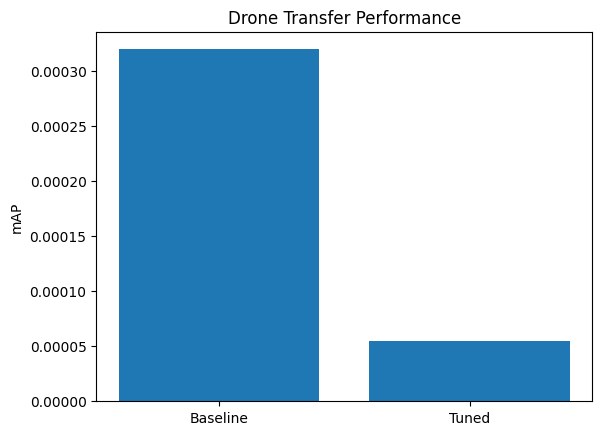

In [ ]:
import matplotlib.pyplot as plt

labels = ["Baseline", "Tuned"]
mAP_vals = [0.0003196, 0.000055]

plt.bar(labels, mAP_vals)
plt.title("Drone Transfer Performance")
plt.ylabel("mAP")
plt.show()

Link to W&B project: https://wandb.ai/jli43-new-jersey-institute-of-technology/faster-rcnn-optuna-coco-minitrain?nw=nwuserjli43

In [ ]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch

def visualize_predictions(model, coco, img_dir, num_images=5):
    model.eval()

    img_ids = coco.getImgIds()
    sample_ids = random.sample(img_ids, num_images)

    for img_id in sample_ids:
        img_info = coco.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, img_info['file_name'])

        image = Image.open(img_path).convert("RGB")
        img_tensor = torchvision.transforms.functional.to_tensor(image).to(device)

        with torch.no_grad():
            outputs = model([img_tensor])[0]

        fig, ax = plt.subplots(1, figsize=(8,6))
        ax.imshow(image)

        boxes = outputs['boxes'].cpu().numpy()
        scores = outputs['scores'].cpu().numpy()

        for box, score in zip(boxes, scores):
            if score < 0.3:
                continue

            x1, y1, x2, y2 = box
            rect = patches.Rectangle(
                (x1, y1),
                x2-x1,
                y2-y1,
                linewidth=2,
                edgecolor='red',
                facecolor='none'
            )

            ax.add_patch(rect)
            ax.text(x1, y1, f"{score:.2f}", color="yellow", fontsize=10)

        ax.set_title(f"Predictions for image {img_id}")
        plt.show()

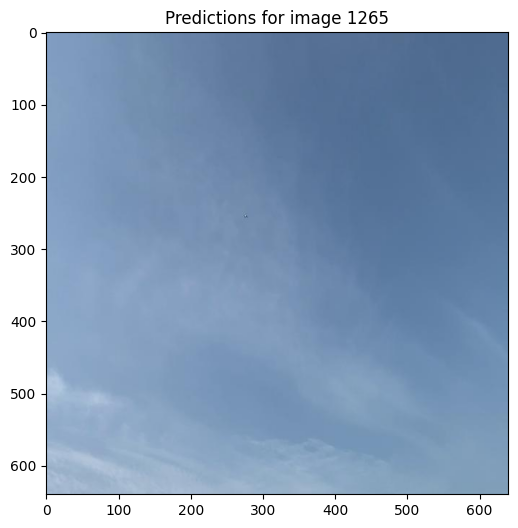

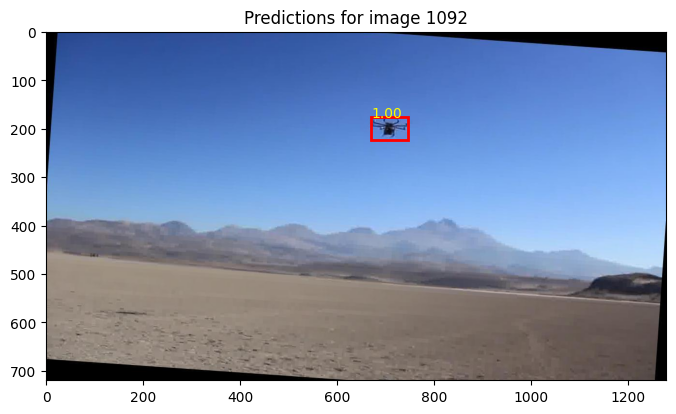

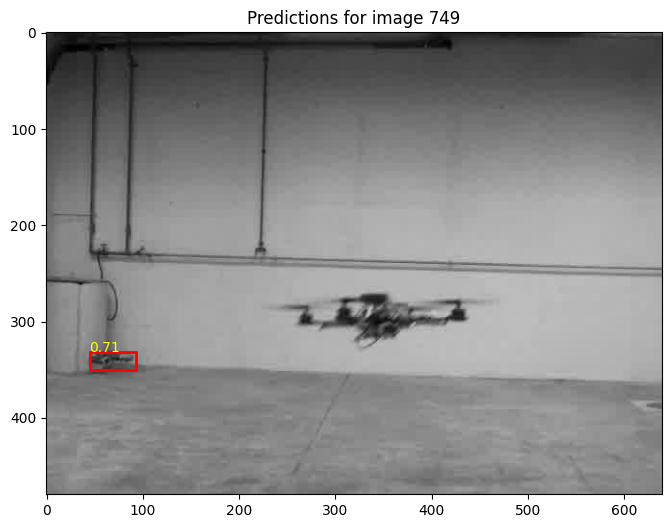

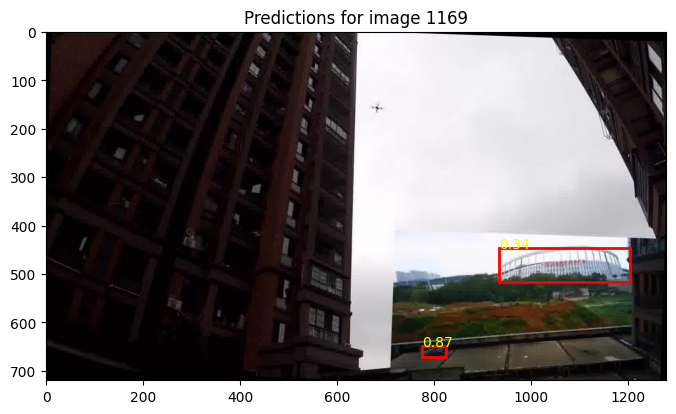

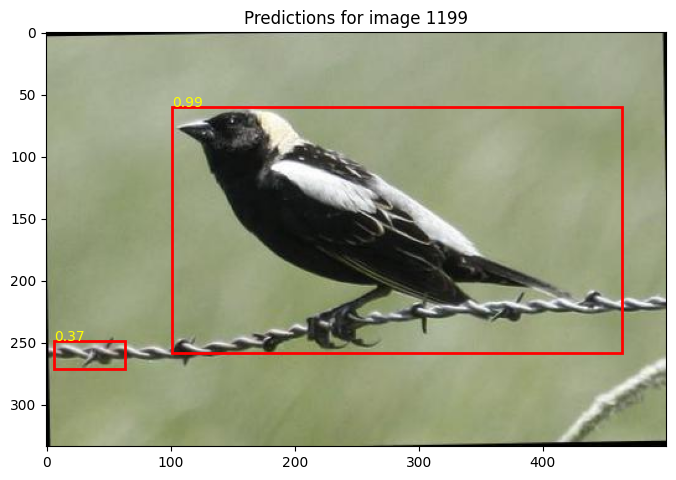

In [ ]:
model = build_model().to(device)
model.load_state_dict(torch.load(ckpts[0], map_location=device))

apply_rpn_hparams(model, best_full)
apply_roi_hparams(model, best_full)
apply_postprocess_hparams(model, best_full)

visualize_predictions(model, drone_coco, DRONE_IMAGES_DIR, num_images=5)